# datetime 오브젝트 사용하기

In [5]:
from datetime import datetime

now1 = datetime.now() 
print(now1)

now2 = datetime.today()
print(now2) 

t1 = datetime.now() 
t2 = datetime(1970, 1, 1)
t3 = datetime(1970, 12, 12, 13, 24, 34)

print(t1)
print(t2)
print(t3)

diff1 = t1-t2

print(diff1)
print(type(diff1))

diff2 = t2-t1

print(diff2)
print(type(diff2))

2026-09-08 01:27:42.681229
2026-09-08 01:27:42.681449
2026-09-08 01:27:42.681535
1970-01-01 00:00:00
1970-12-12 13:24:34
20704 days, 1:27:42.681535
<class 'datetime.timedelta'>
-20705 days, 22:32:17.318465
<class 'datetime.timedelta'>


# 문자열을 datetime 오브젝트로 변환하기

In [9]:
import pandas as pd 
import os
ebola = pd.read_csv('../data/country_timeseries.csv')

print(ebola.info())
print('\n')

ebola['date_dt'] = pd.to_datetime(ebola['Date'])
print(ebola.info())

test_df1 = pd.DataFrame({'order_day':['01/01/15', '02/01/15', '03/01/15']})

test_df1['date_dt1'] = pd.to_datetime(test_df1['order_day'], format='%d/%m/%y')
test_df1['date_dt2'] = pd.to_datetime(test_df1['order_day'], format='%m/%d/%y')
test_df1['date_dt3'] = pd.to_datetime(test_df1['order_day'], format='%y/%m/%d')

print(test_df1)

test_df2 = pd.DataFrame({'order_day':['01-01-15', '02-01-15', '03-01-15']})
test_df2['date_dt'] = pd.to_datetime(test_df2['order_day'], format='%d-%m-%y')

print(test_df2)

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    str    
 1   Day                  122 non-null    int64  
 2   Cases_Guinea         93 non-null     float64
 3   Cases_Liberia        83 non-null     float64
 4   Cases_SierraLeone    87 non-null     float64
 5   Cases_Nigeria        38 non-null     float64
 6   Cases_Senegal        25 non-null     float64
 7   Cases_UnitedStates   18 non-null     float64
 8   Cases_Spain          16 non-null     float64
 9   Cases_Mali           12 non-null     float64
 10  Deaths_Guinea        92 non-null     float64
 11  Deaths_Liberia       81 non-null     float64
 12  Deaths_SierraLeone   87 non-null     float64
 13  Deaths_Nigeria       38 non-null     float64
 14  Deaths_Senegal       22 non-null     float64
 15  Deaths_UnitedStates  18 non-null     float64
 16  D

# 시간 데이터를 잘라내고 싶어요

In [10]:
now = datetime.now()
print(now)

nowDate = now.strftime('%Y-%m-%d')
print(nowDate)

nowTime = now.strftime('%H:%M:%S')
print(nowTime) 

nowDatetime = now.strftime('%Y-%m-%d %H:%M:%S')
print(nowDatetime) 

2026-09-08 01:29:34.896244
2026-09-08
01:29:34
2026-09-08 01:29:34


# datetime 오브젝트로 변환하려는 열을 지정하여 데이터 집합 불러오기

In [11]:
ebola1 = pd.read_csv('../data/country_timeseries.csv', parse_dates=['Date']) 
print(ebola1.info())

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    datetime64[us]
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null     float64  

# datetime 오브젝트에서 날짜 정보 추출하기

In [13]:
date_series = pd.Series(['2018-05-16', '2018-05-17', '2018-05-18'])
d1 = pd.to_datetime(date_series) 
print(d1)
print(d1[0].year)
print(d1[0].month)
print(d1[0].day)

0   2018-05-16
1   2018-05-17
2   2018-05-18
dtype: datetime64[us]
2018
5
16


# dt 접근자로 시간 데이터 정리하기

In [18]:
ebola = pd.read_csv('../data/country_timeseries.csv')
ebola['date_dt'] = pd.to_datetime(ebola['Date'])

print(ebola[['Date', 'date_dt']].head())
print(ebola['date_dt'][3].year)
print(ebola['date_dt'][3].month)
print(ebola['date_dt'][3].day)

print('\n')
ebola['year'] = ebola['date_dt'].dt.year
print(ebola[['Date', 'date_dt', 'year']].head())

ebola['month'], ebola['day'] = (ebola['date_dt'].dt.month, ebola['date_dt'].dt.day)
print(ebola[['Date', 'date_dt', 'year', 'month', 'day']].head())
print(ebola.info())

         Date    date_dt
0    1/5/2015 2015-01-05
1    1/4/2015 2015-01-04
2    1/3/2015 2015-01-03
3    1/2/2015 2015-01-02
4  12/31/2014 2014-12-31
2015
1
2


         Date    date_dt  year
0    1/5/2015 2015-01-05  2015
1    1/4/2015 2015-01-04  2015
2    1/3/2015 2015-01-03  2015
3    1/2/2015 2015-01-02  2015
4  12/31/2014 2014-12-31  2014
         Date    date_dt  year  month  day
0    1/5/2015 2015-01-05  2015      1    5
1    1/4/2015 2015-01-04  2015      1    4
2    1/3/2015 2015-01-03  2015      1    3
3    1/2/2015 2015-01-02  2015      1    2
4  12/31/2014 2014-12-31  2014     12   31
<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    str           
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liber

# 에볼라 최초 발생일 계산해보기

In [19]:
print(ebola.iloc[-5:, :5])

print(ebola['date_dt'].min())
print(type(ebola['date_dt'].min()))

ebola['outbreak_d'] = ebola['date_dt'] - ebola['date_dt'].min()
print(ebola[['Date', 'Day', 'outbreak_d']].head())

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117  3/27/2014    5         103.0            8.0                6.0
118  3/26/2014    4          86.0            NaN                NaN
119  3/25/2014    3          86.0            NaN                NaN
120  3/24/2014    2          86.0            NaN                NaN
121  3/22/2014    0          49.0            NaN                NaN
2014-03-22 00:00:00
<class 'pandas.Timestamp'>
         Date  Day outbreak_d
0    1/5/2015  289   289 days
1    1/4/2015  288   288 days
2    1/3/2015  287   287 days
3    1/2/2015  286   286 days
4  12/31/2014  284   284 days


# 파산한 은행의 개수 계산하기

                                           Bank Name         City  ST   CERT  \
0                Washington Federal Bank for Savings      Chicago  IL  30570   
1    The Farmers and Merchants State Bank of Argonia      Argonia  KS  17719   
2                                Fayette County Bank   Saint Elmo  IL   1802   
3  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...    Milwaukee  WI  30003   
4                                     First NBC Bank  New Orleans  LA  58302   

                 Acquiring Institution Closing Date Updated Date  
0                   Royal Savings Bank    15-Dec-17    20-Dec-17  
1                          Conway Bank    13-Oct-17    20-Oct-17  
2            United Fidelity Bank, fsb    26-May-17    26-Jul-17  
3  First-Citizens Bank & Trust Company     5-May-17    26-Jul-17  
4                         Whitney Bank    28-Apr-17     5-Dec-17  
<class 'pandas.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 7 columns):
 #   Column             

C:\Users\a7922\AppData\Local\Temp\ipykernel_12232\1555624870.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('../data/banklist.csv', parse_dates=[5, 6])
C:\Users\a7922\AppData\Local\Temp\ipykernel_12232\1555624870.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('../data/banklist.csv', parse_dates=[5, 6])


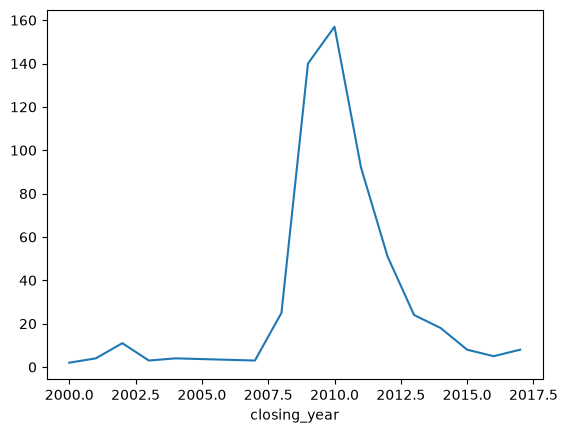

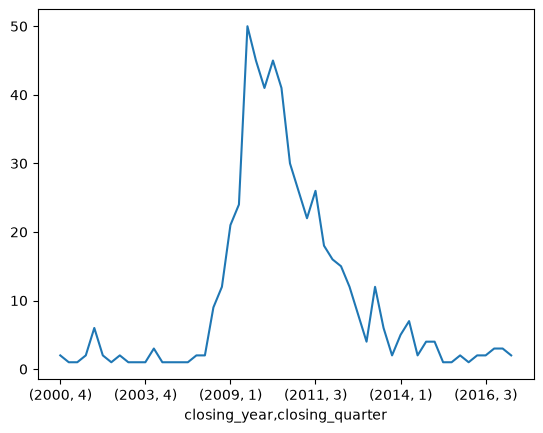

In [23]:
banks = pd.read_csv('../data/banklist.csv') 
print(banks.head())

banks_no_dates = pd.read_csv('../data/banklist.csv')
print(banks_no_dates.info())

banks = pd.read_csv('../data/banklist.csv', parse_dates=[5, 6]) 
print(banks.info())

banks['closing_quarter'], banks['closing_year'] = (banks['Closing Date'].dt.quarter, banks['Closing Date'].dt.year)
print(banks.head())

closing_year = banks.groupby(['closing_year']).size()
print(closing_year)

closing_year_q = banks.groupby(['closing_year', 'closing_quarter']).size()
print(closing_year_q)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax = closing_year.plot() 
plt.show()
fig, ax = plt.subplots() 
ax = closing_year_q.plot() 
plt.show()

# 테슬라 주식 데이터로 시간 계산하기

In [25]:
pd.core.common.is_list_like = pd.api.types.is_list_like
import pandas_datareader as pdr

tesla = pdr.get_data_quandl('TSLA', api_key = '받은 key')
tesla.to_csv('../data/tesla_stock_quandl.csv')

print(tesla.head())

tesla = pd.read_csv('../data/tesla_stock_quandl.csv', parse_dates=[0])
print(tesla.info())

print(tesla.loc[(tesla.Date.dt.year == 2010) & (tesla.Date.dt.month == 6)])

AttributeError: module 'pandas_datareader' has no attribute 'get_data_quandl'

# datetime 오브젝트를 인덱스로 설정하여 데이터 추출하기

In [26]:
tesla.index = tesla['Date'] 
print(tesla.index)

print(tesla['2015'].iloc[:5, :5])

print(tesla['2010-06'].iloc[:, :5])

NameError: name 'tesla' is not defined

# 시간 간격을 인덱스로 설정하여 데이터 추출하기

In [27]:
tesla['ref_date'] = tesla['Date'] - tesla['Date'].min()
print(tesla.head())

tesla.index = tesla['ref_date']
print(tesla.iloc[:5, :5])
print(tesla['5 days':].iloc[:5, :5])

NameError: name 'tesla' is not defined

# 시간 범위 생성하여 인덱스로 지정하기

In [29]:
ebola = pd.read_csv('../data/country_timeseries.csv', parse_dates=[0]) 
print(ebola.iloc[:5, :5])

print(ebola.iloc[-5:, :5])

head_range = pd.date_range(start='2014-12-31', end='2015-01-05') 
print(head_range)

ebola_5 = ebola.head()
ebola_5.index = ebola_5['Date']
ebola_5.reindex(head_range)
print(ebola_5.iloc[:5, :5])

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0
          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117 2014-03-27    5         103.0            8.0                6.0
118 2014-03-26    4          86.0            NaN                NaN
119 2014-03-25    3          86.0            NaN                NaN
120 2014-03-24    2          86.0            NaN                NaN
121 2014-03-22    0          49.0            NaN                NaN
DatetimeIndex(['2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[us]', freq='D')
                 Date  Day  Cases

# 시간 범위의 주기 설정하기

In [30]:
print(pd.date_range('2017-01-01', '2017-01-07', freq='B'))

DatetimeIndex(['2017-01-02', '2017-01-03', '2017-01-04', '2017-01-05',
               '2017-01-06'],
              dtype='datetime64[us]', freq='B')


# 에볼라 발병 시간 비교하기

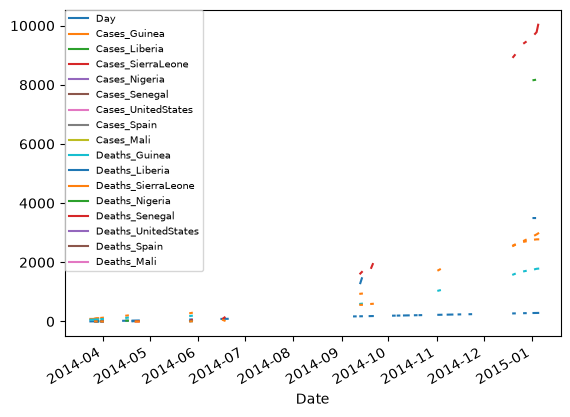

            Day  Cases_Guinea  Cases_Liberia
Date                                        
2014-03-31  9.0         122.0            8.0
NaT         NaN           NaN            NaN
2014-03-29  7.0         112.0            7.0
2014-03-28  6.0         112.0            3.0
2014-03-27  5.0         103.0            8.0
2014-03-26  4.0          86.0            NaN
2014-03-25  3.0          86.0            NaN
2014-03-24  2.0          86.0            NaN
NaT         NaN           NaN            NaN
2014-03-22  0.0          49.0            NaN
        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0
          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLe

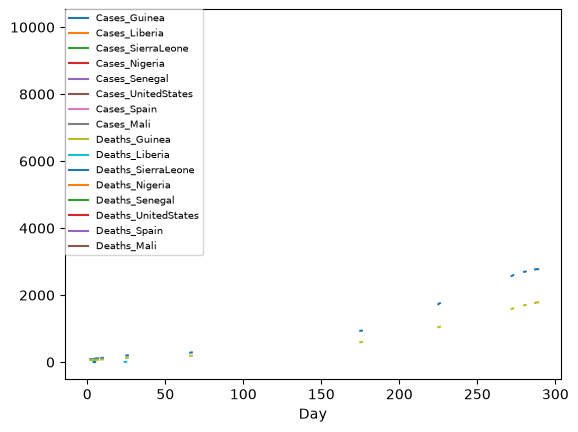

In [39]:
import matplotlib.pyplot as plt

ebola.index = ebola['Date']

fig, ax = plt.subplots() 
ax = ebola.iloc[0:, 1:].plot(ax=ax)
ax.legend(fontsize=7, loc=2, borderaxespad=0.) 
plt.show()

ebola_sub = ebola[['Day', 'Cases_Guinea', 'Cases_Liberia']] 
print(ebola_sub.tail(10))

ebola = pd.read_csv('../data/country_timeseries.csv',  parse_dates=['Date'])

print(ebola.head().iloc[:, :5])
print(ebola.tail().iloc[:, :5])

ebola.index = ebola['Date']
new_idx = pd.date_range(ebola.index.min(), ebola.index.max())

print(new_idx)
new_idx = reversed(new_idx)
ebola = ebola.reindex(new_idx)
print(ebola.head().iloc[:, :5])
print(ebola.tail().iloc[:, :5])

last_valid = ebola.apply(pd.Series.last_valid_index) 
print(last_valid)

first_valid = ebola.apply(pd.Series.first_valid_index) 
print(first_valid)

earliest_date = ebola.index.min() 
print(earliest_date)

shift_values = last_valid - earliest_date 
print(shift_values)

print('\n')
ebola_dict = {} 
for idx, col in enumerate(ebola):
    d = shift_values.iloc[idx].days 
    shifted = ebola[col].shift(d) 
    ebola_dict[col] = shifted

ebola_shift = pd.DataFrame(ebola_dict)
print(ebola_shift.tail())
print('\n')

ebola_shift.index = ebola_shift['Day'] 
ebola_shift = ebola_shift.drop(['Date', 'Day'], axis=1)
print(ebola_shift.tail())

fig, ax = plt.subplots() 
ax = ebola_shift.iloc[:, :].plot(ax=ax)
ax.legend(fontsize=7, loc=2, borderaxespad=0.) 
plt.show()